In [1]:
import json, warnings, itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import (LeaveOneGroupOut, cross_val_predict,
                                      KFold, cross_val_score, GridSearchCV)
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
import json, sys, glob, warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)

print("Libraries loaded successfully.")


def load_data(pa):
    trans = []
    data = json.load(open(pa, encoding="utf-8"))
    for ri, run in enumerate(data["runs"]):
        meta = run["metadata"]
        v = meta["v"]; cost = meta["product"]["cost"]; market = meta["product"]["market_price"]
        rounds = run["rounds"]
        m_init = rounds[0]["buyer_price"]; s_init = rounds[0]["supplier_price"]
        for i in range(1, len(rounds)):
            prev, curr = rounds[i-1], rounds[i]
            sp, mc, sc = prev["supplier_price"], curr["buyer_price"], curr["supplier_price"]
            if sp is None or sc is None:
                continue
            trans.append(dict(
                m_t=mc, s_prev=sp, s_t=sc, v=v, cost=cost, market=market,
                round_t=curr["round"], buyer_type=meta["buyer_type"]["name"],
                product=meta["product"]["name"], supplier_id=meta["supplier"]["id"],
                m_init=m_init, s_init=s_init if s_init else np.nan,
                m_prev=prev["buyer_price"], template_id=curr.get("template_id", -1),
                s_prev2=rounds[i-2]["supplier_price"] if i >= 2 else None,
                run_idx=ri,
                m_prev2=rounds[i-2]["buyer_price"] if i >= 2 else None,
                s_prev3=rounds[i-3]["supplier_price"] if i >= 3 else None,
                m_prev3=rounds[i-3]["buyer_price"] if i >= 3 else None
            ))
    return trans

all_data = []
for f in sorted(glob.glob(str("tit_for_tat_matcher/random__*.json"))):
    if "transitions" in f: continue
    else:
        all_data.extend(load_data(f))

for f in sorted(glob.glob(str("tit_for_tat_matcher/wild__*.json"))):
    if "transitions" in f: continue
    else:
        all_data.extend(load_data(f))

for f in sorted(glob.glob(str("tit_for_tat_matcher/budget__*.json"))):
    if "transitions" in f: continue
    else:
        all_data.extend(load_data(f))


for f in sorted(glob.glob(str("tit_for_tat_matcher/concession__*.json"))):
    if "transitions" in f: continue
    else:
        all_data.extend(load_data(f))




df = pd.DataFrame(all_data)
df['region'] = np.where(df['m_t'] < df['v'], 'Low',
                np.where(df['m_t'] > df['s_prev'], 'High', 'Negotiation'))
print(f"Dataset: {df.shape[0]} observations × {df.shape[1]} columns")
print(f"Runs: {df['run_idx'].nunique()}, samples per run: {df.groupby('run_idx').size().unique()}")
print(df.head(5))


Libraries loaded successfully.
Dataset: 3266 observations × 20 columns
Runs: 20, samples per run: [256 264 263 258 260 261  64  66]
    m_t  s_prev   s_t    v  cost  market  round_t buyer_type       product  \
0  0.85    1.10  0.95  0.7   0.3     1.5        2     random  Cola (330ml)   
1  1.31    0.95  1.25  0.7   0.3     1.5        3     random  Cola (330ml)   
2  0.78    1.25  1.25  0.7   0.3     1.5        4     random  Cola (330ml)   
3  1.01    1.25  1.15  0.7   0.3     1.5        5     random  Cola (330ml)   
4  1.45    1.15  1.40  0.7   0.3     1.5        6     random  Cola (330ml)   

  supplier_id  m_init  s_init  m_prev  template_id  s_prev2  run_idx  m_prev2  \
0          S1    0.58     1.1    0.58            6      NaN        0      NaN   
1          S1    0.58     1.1    0.85            5     1.10        0     0.58   
2          S1    0.58     1.1    1.31            4     0.95        0     0.85   
3          S1    0.58     1.1    0.78            1     1.25        0     1.


===== I.I.D. Split Results =====
          model   dataset  n_features  r2_train  r2_val  rmse_train  rmse_val  \
8     OLS_accel     accel          14    0.9922  0.9941      0.2153    0.1898   
7      OLS_full      full          13    0.9927  0.9928      0.2111    0.2033   
5  OLS_relative  relative           8    0.9927  0.9928      0.2117    0.2034   
4  OLS_interact  interact           8    0.9924  0.9924      0.2160    0.2087   
3      OLS_lag2      lag2           6    0.9923  0.9923      0.2171    0.2092   
6    OLS_region    region           9    0.9923  0.9923      0.2171    0.2092   
1      OLS_core      core           3    0.9906  0.9896      0.2396    0.2511   
2      OLS_more      more           4    0.9907  0.9894      0.2372    0.2527   
0  OLS_baseline  baseline           2    0.4961  0.4846      1.7501    1.7659   

   mae_train  mae_val  
8     0.1140   0.1098  
7     0.1109   0.1054  
5     0.1103   0.1046  
4     0.1122   0.1053  
3     0.1104   0.1033  
6     0.110

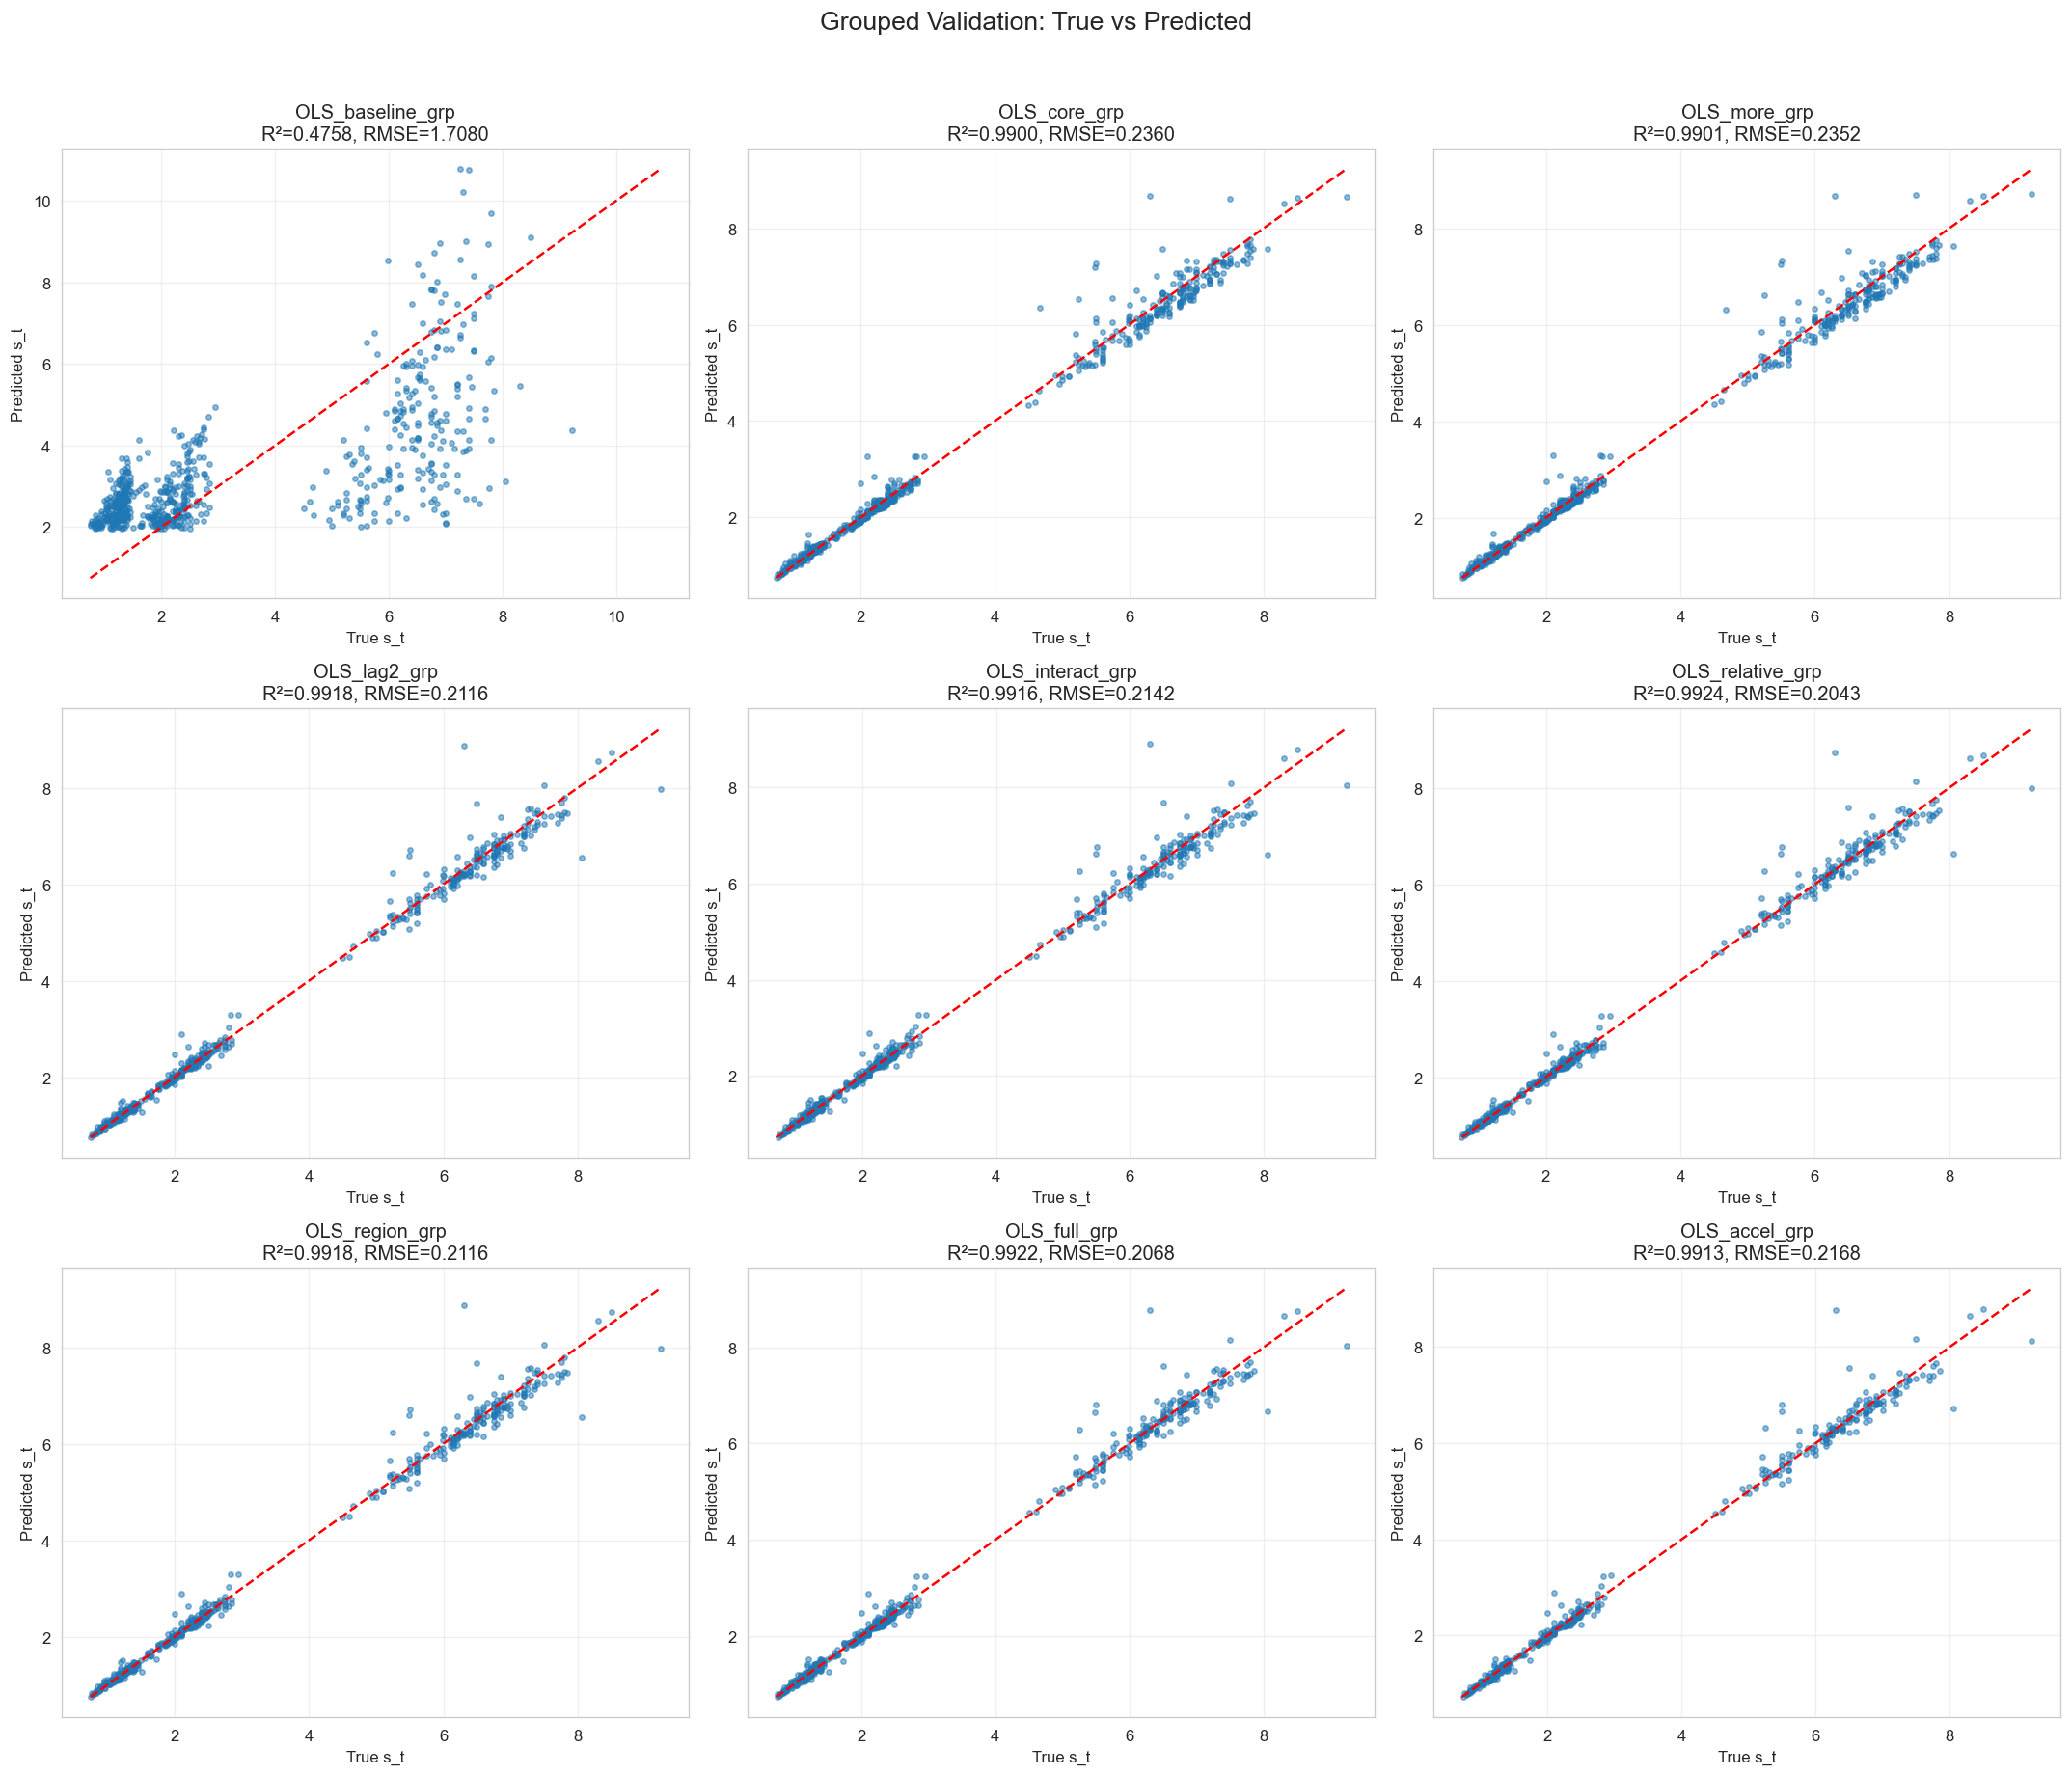

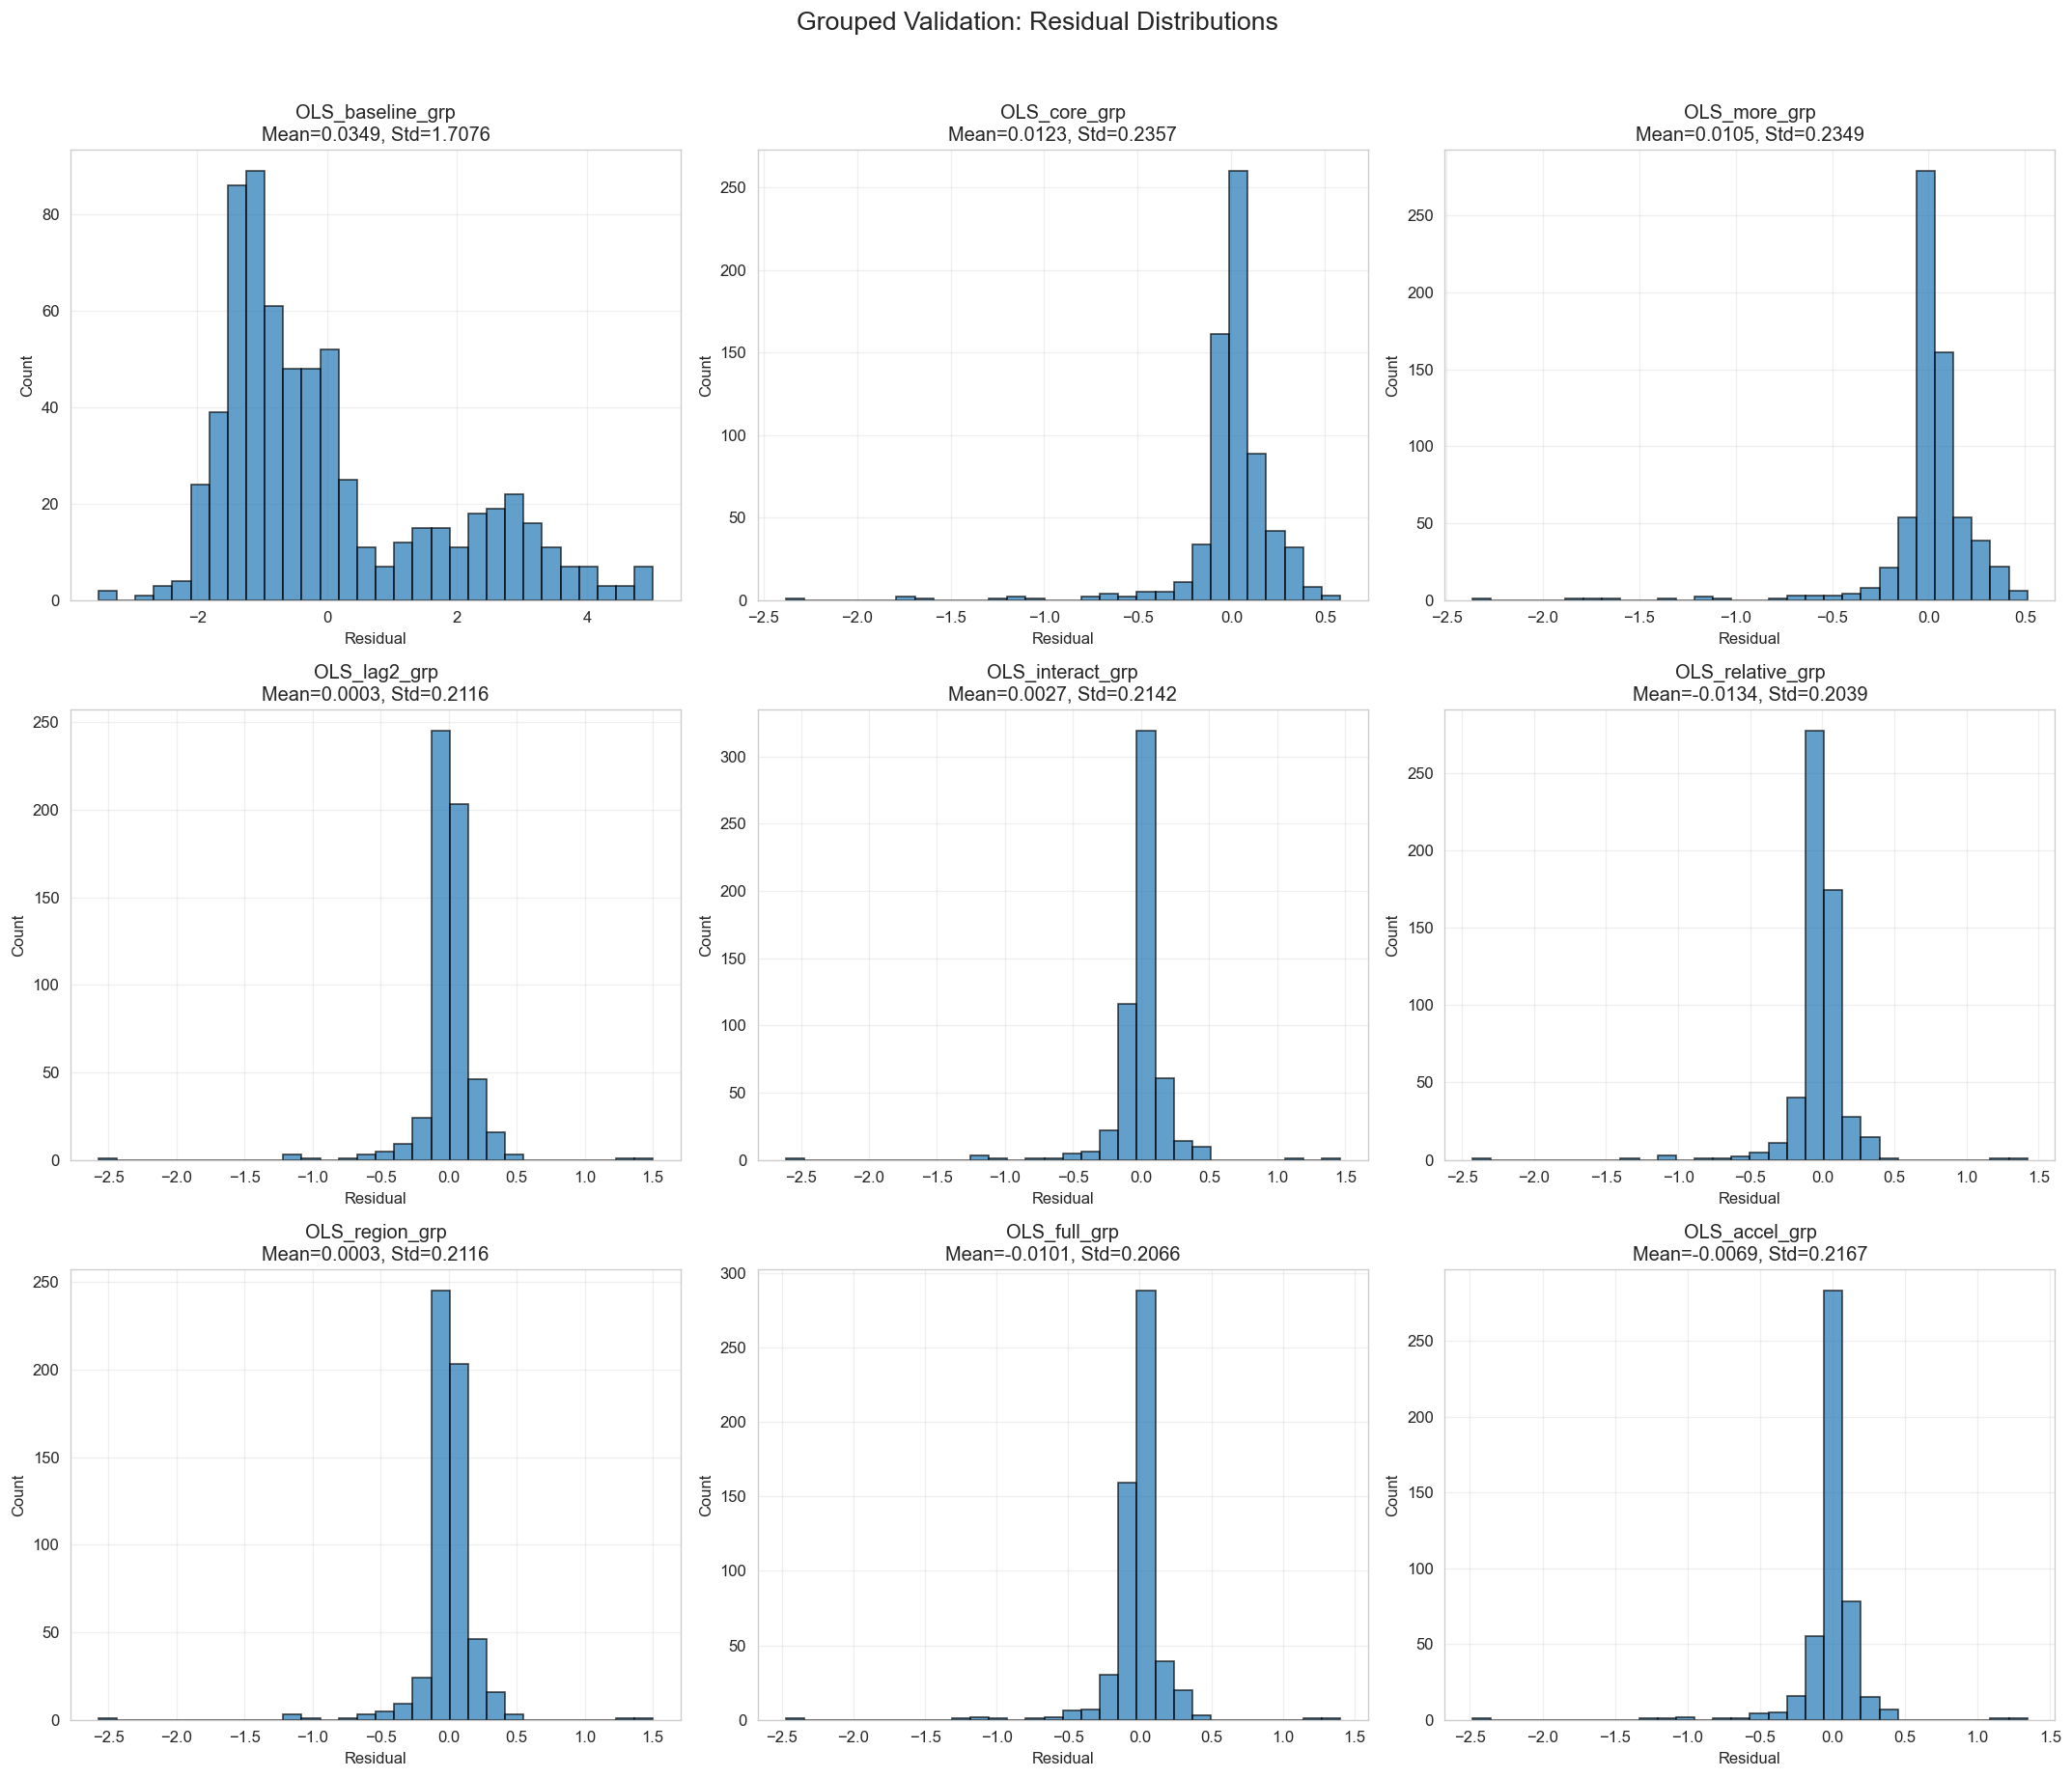

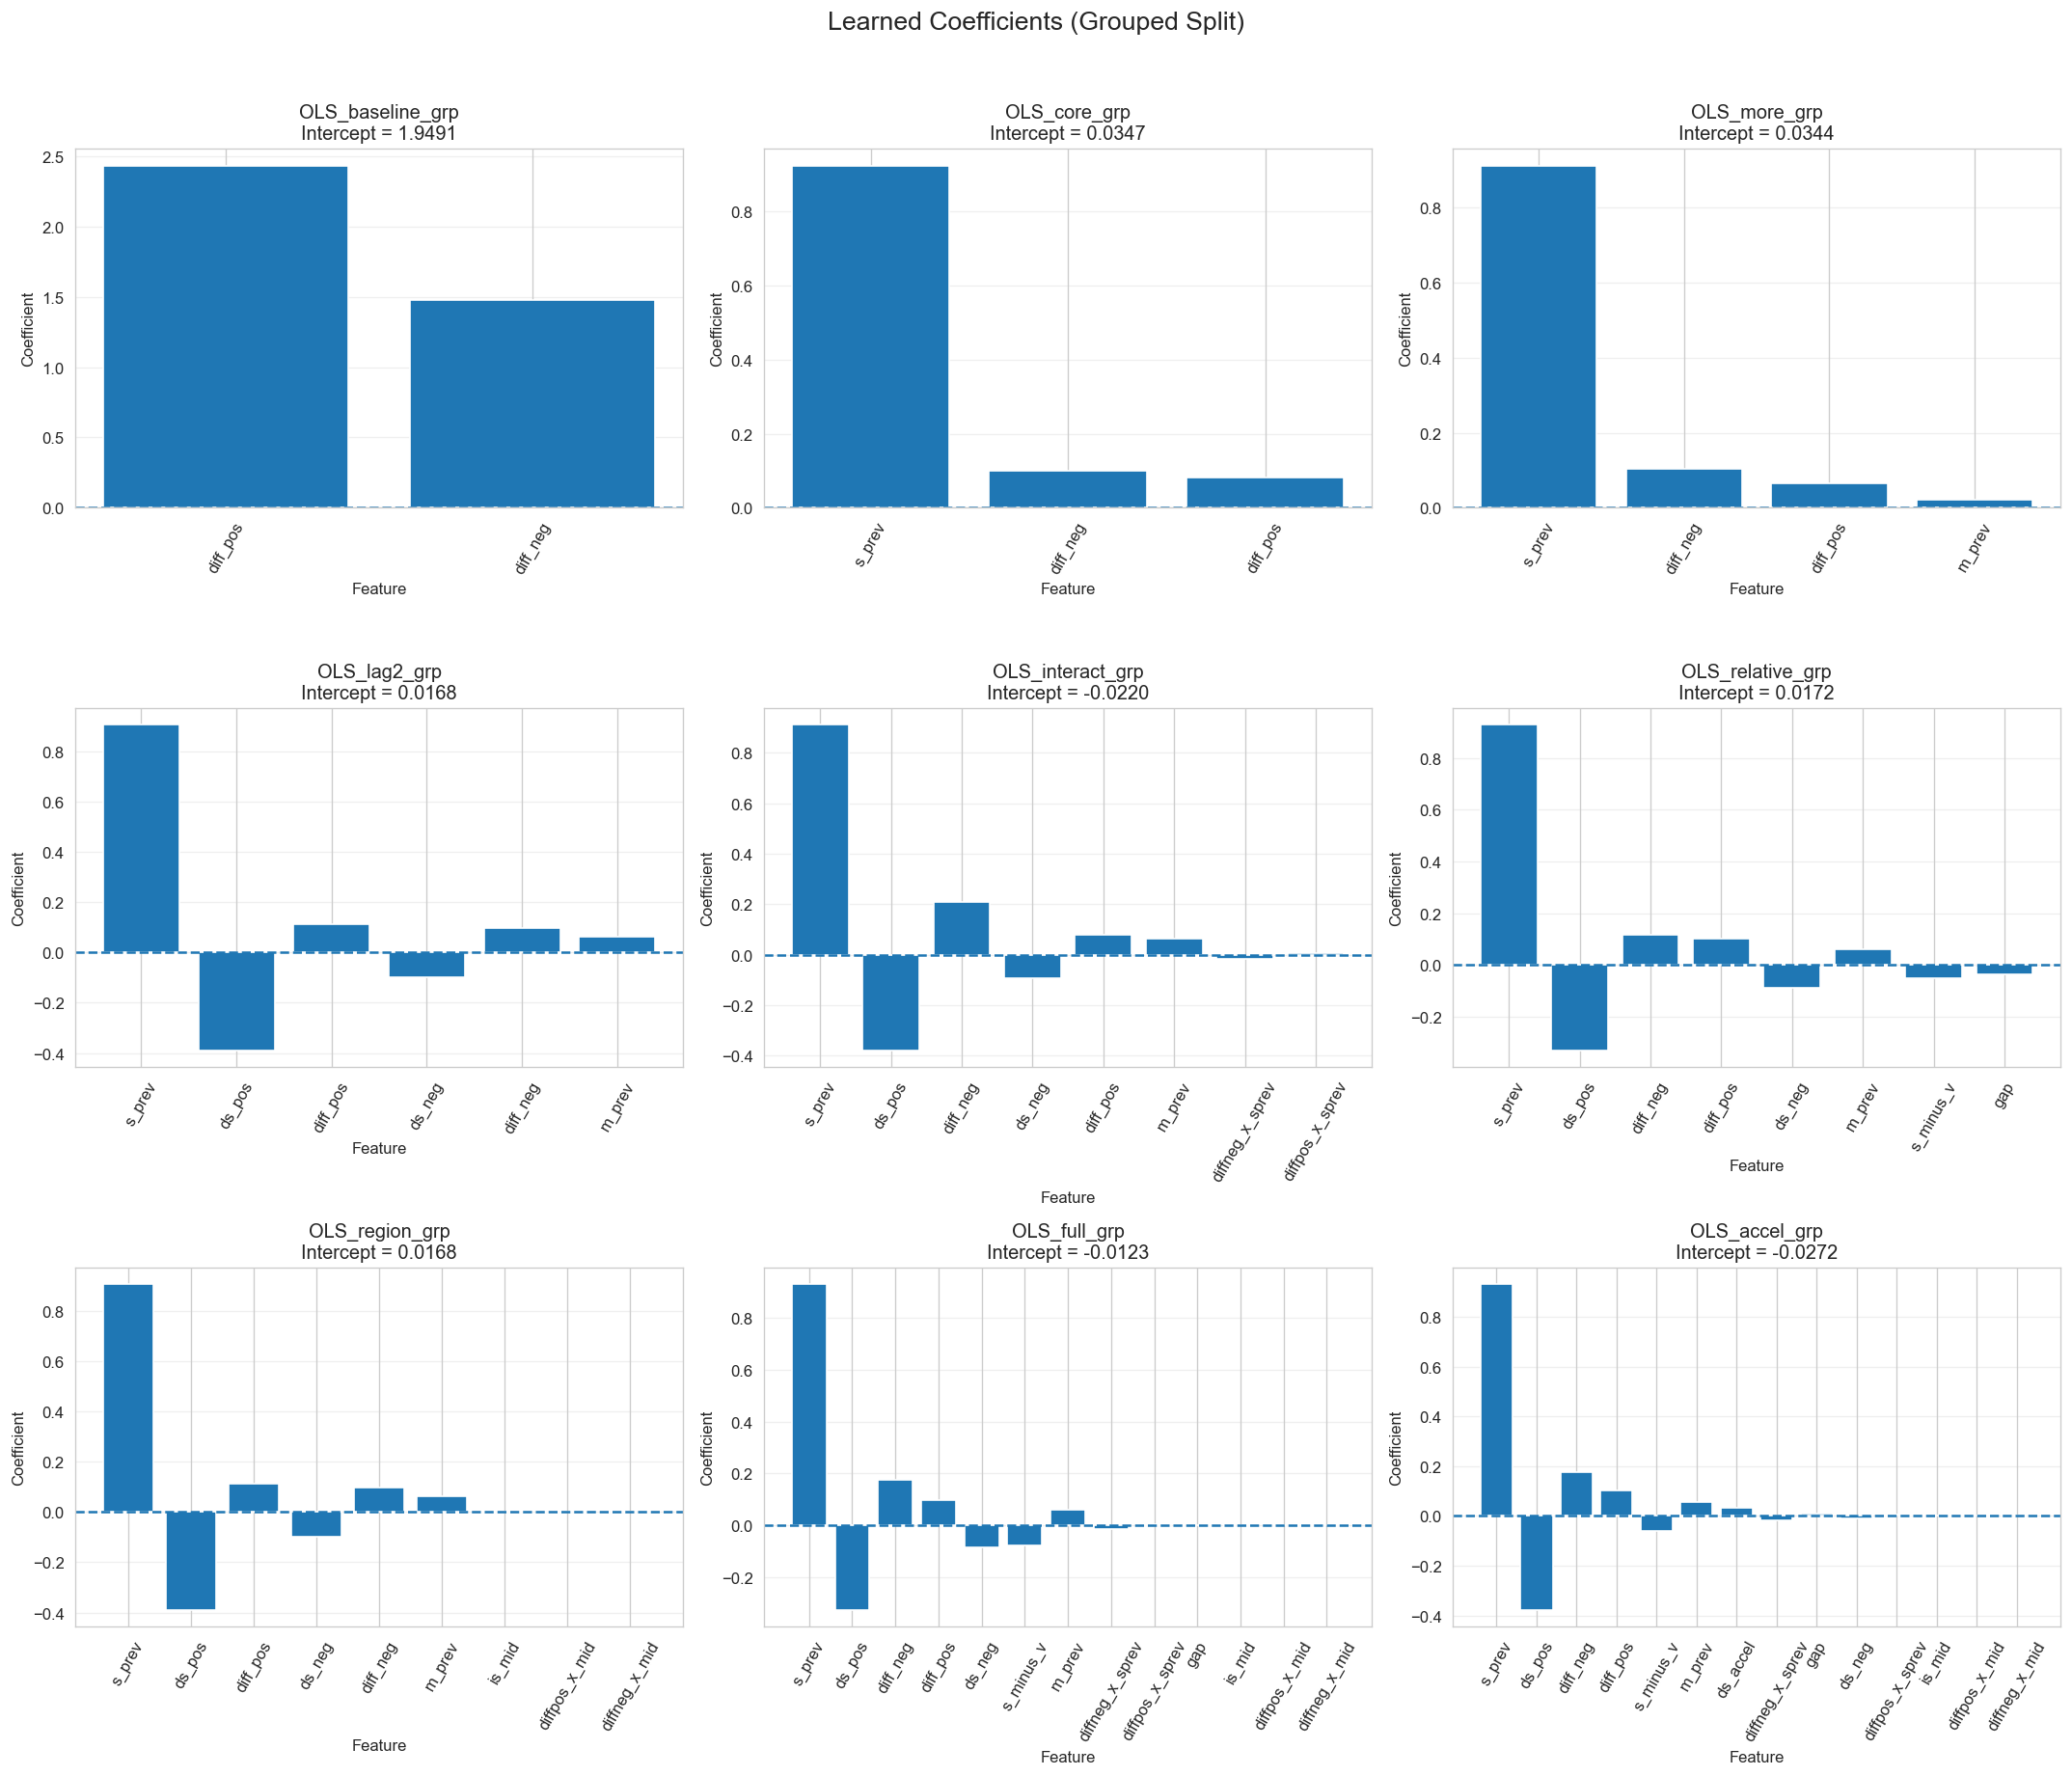

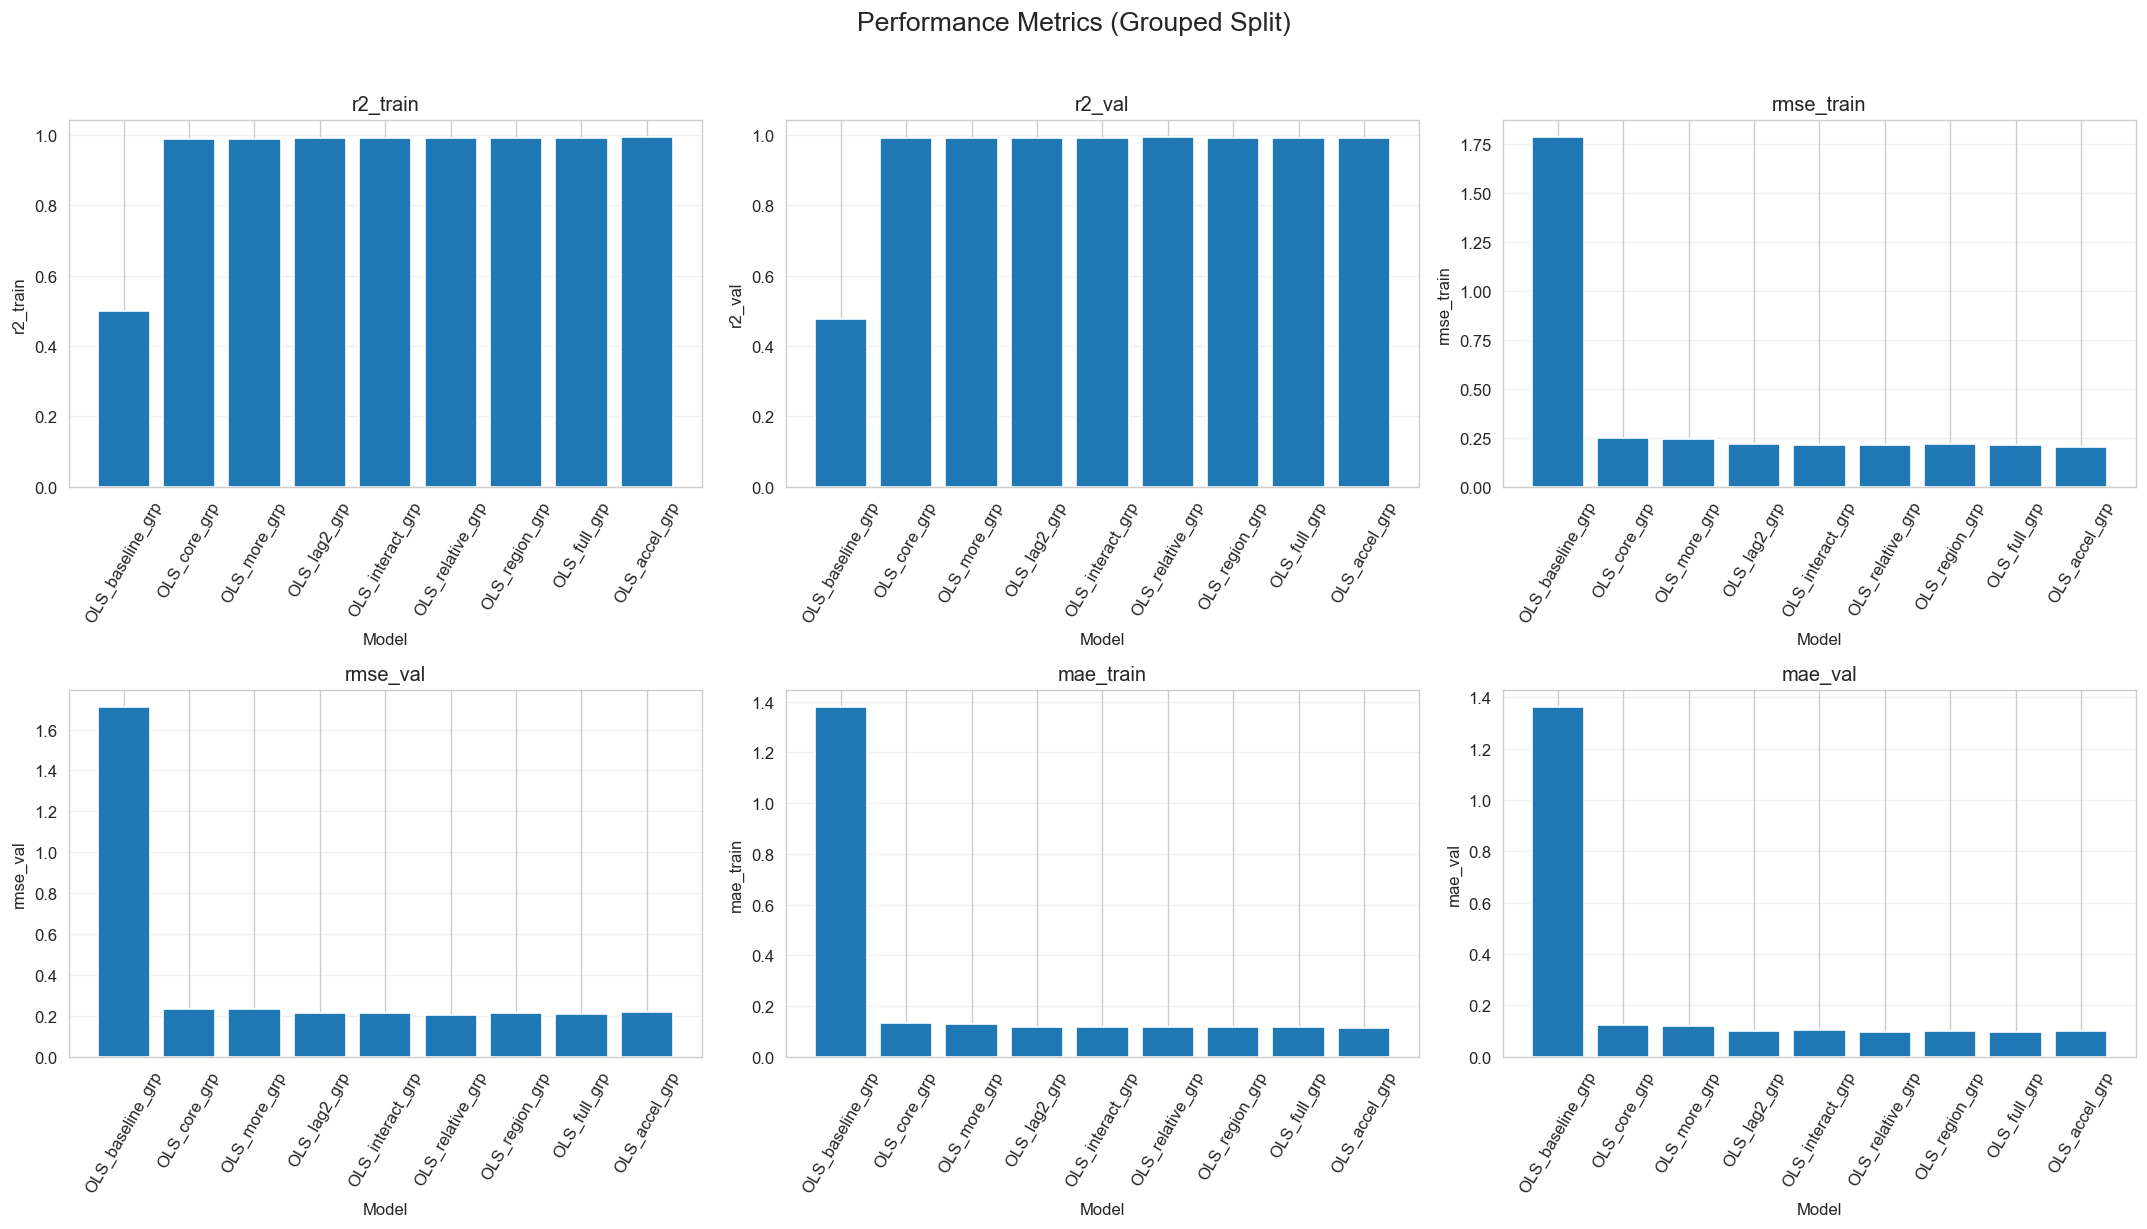


===== Best Grouped Validation Model by R^2 =====
model         OLS_relative_grp
dataset               relative
n_features                   8
r2_train              0.992805
r2_val                0.992383
rmse_train            0.212882
rmse_val              0.204315
mae_train              0.11578
mae_val               0.094959
Name: 5, dtype: object


In [2]:
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error


# =========================================================
# Feature engineering
# =========================================================

df_target = df[(df['region'] != "High") & (df['round_t'] <= 8)].copy()

# Hinge on (m_t - v)
df_target['diff_pos'] = np.maximum(df_target['m_t'] - df_target['v'], 0)
df_target['diff_neg'] = np.maximum(df_target['v'] - df_target['m_t'], 0)

# Hinge on (s_{t-1} - s_{t-2})
df_target['ds_prev'] = df_target['s_prev'] - df_target['s_prev2']
df_target['ds_pos']  = np.maximum(df_target['ds_prev'], 0)
df_target['ds_neg']  = np.maximum(-df_target['ds_prev'], 0)

# Interactions: hinge × s_prev
df_target['diffpos_x_sprev'] = df_target['diff_pos'] * df_target['s_prev']
df_target['diffneg_x_sprev'] = df_target['diff_neg'] * df_target['s_prev']

# Relative position features
df_target['s_minus_v'] = df_target['s_prev'] - df_target['v']
df_target['gap']       = df_target['s_prev'] - df_target['m_t']

# Concession acceleration: (ds_t - ds_{t-1})
# ds_prev = s_{t-1} - s_{t-2}, ds_prev2 = s_{t-2} - s_{t-3}
df_target['ds_prev2'] = df_target['s_prev2'] - df_target['s_prev3'] if 's_prev3' in df_target.columns else np.nan
if 's_prev3' in df_target.columns:
    df_target['ds_accel'] = df_target['ds_prev'] - df_target['ds_prev2']

# Region dummy
df_target['is_mid'] = (df_target['region'] == 'Mid').astype(int)

# Region × hinge interactions
df_target['diffpos_x_mid'] = df_target['diff_pos'] * df_target['is_mid']
df_target['diffneg_x_mid'] = df_target['diff_neg'] * df_target['is_mid']


# =========================================================
# Feature sets
# =========================================================

baseline_features = ['diff_pos', 'diff_neg']

core_features = ['diff_pos', 'diff_neg', 's_prev']

more_features = ['diff_pos', 'diff_neg', 's_prev', 'm_prev']

lag2_features = [
    'diff_pos', 'diff_neg', 'ds_pos', 'ds_neg', 's_prev', 'm_prev'
]

# === New extended sets ===

# lag2 + interactions with s_prev
interact_features = lag2_features + [
    'diffpos_x_sprev', 'diffneg_x_sprev',
]

# lag2 + relative position
relative_features = lag2_features + [
    's_minus_v', 'gap',
]

# lag2 + region dummies & interactions
region_features = lag2_features + [
    'is_mid', 'diffpos_x_mid', 'diffneg_x_mid',
]

# full: everything combined
full_features = lag2_features + [
    'diffpos_x_sprev', 'diffneg_x_sprev',
    's_minus_v', 'gap',
    'is_mid', 'diffpos_x_mid', 'diffneg_x_mid',
]

# full + acceleration (needs s_prev3)
if 's_prev3' in df_target.columns:
    accel_features = full_features + ['ds_accel']
else:
    accel_features = None


# =========================================================
# Datasets
# =========================================================

def make_dataset(df_src, feature_list, dropna_cols=None):
    """Build X, y, groups from df_src, dropping NaN in dropna_cols."""
    if dropna_cols is None:
        dropna_cols = feature_list
    df_clean = df_src.dropna(subset=dropna_cols).copy()
    X = df_clean[feature_list].values.copy()
    y = df_clean['s_t'].values.copy()
    groups = df_clean['run_idx'].values.copy()
    return X, y, groups


x_baseline, y_baseline, g_baseline = make_dataset(df_target, baseline_features)
x_core, y_core, g_core             = make_dataset(df_target, core_features)
x_more, y_more, g_more             = make_dataset(df_target, more_features)
x_lag2, y_lag2, g_lag2             = make_dataset(df_target, lag2_features,
                                                   dropna_cols=['s_prev2', 'm_prev2'])
x_interact, y_interact, g_interact = make_dataset(df_target, interact_features,
                                                    dropna_cols=['s_prev2', 'm_prev2'])
x_relative, y_relative, g_relative = make_dataset(df_target, relative_features,
                                                    dropna_cols=['s_prev2', 'm_prev2'])
x_region, y_region, g_region       = make_dataset(df_target, region_features,
                                                    dropna_cols=['s_prev2', 'm_prev2'])
x_full, y_full, g_full             = make_dataset(df_target, full_features,
                                                    dropna_cols=['s_prev2', 'm_prev2'])

datasets = {
    "baseline":  (x_baseline,  y_baseline,  g_baseline,  baseline_features),
    "core":      (x_core,      y_core,      g_core,      core_features),
    "more":      (x_more,      y_more,      g_more,      more_features),
    "lag2":      (x_lag2,      y_lag2,      g_lag2,      lag2_features),
    "interact":  (x_interact,  y_interact,  g_interact,  interact_features),
    "relative":  (x_relative,  y_relative,  g_relative,  relative_features),
    "region":    (x_region,    y_region,    g_region,    region_features),
    "full":      (x_full,      y_full,      g_full,      full_features),
}

if accel_features is not None:
    x_accel, y_accel, g_accel = make_dataset(df_target, accel_features,
                                              dropna_cols=['s_prev2', 's_prev3'])
    datasets["accel"] = (x_accel, y_accel, g_accel, accel_features)


# =========================================================
# 1. Evaluation helpers
# =========================================================

def evaluate_linear_model(X, y, feature_names, model_name, test_size=0.3, random_state=42):
    """Standard i.i.d. split."""
    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )
    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred_train = model.predict(X_train)
    y_pred_val = model.predict(X_val)
    return {
        "model_name": model_name, "feature_names": feature_names,
        "X_train": X_train, "X_val": X_val,
        "y_train": y_train, "y_val": y_val,
        "y_pred_train": y_pred_train, "y_pred_val": y_pred_val,
        "r2_train": r2_score(y_train, y_pred_train),
        "r2_val": r2_score(y_val, y_pred_val),
        "rmse_train": np.sqrt(mean_squared_error(y_train, y_pred_train)),
        "rmse_val": np.sqrt(mean_squared_error(y_val, y_pred_val)),
        "mae_train": mean_absolute_error(y_train, y_pred_train),
        "mae_val": mean_absolute_error(y_val, y_pred_val),
        "intercept": model.intercept_, "coef": model.coef_, "model_obj": model,
    }


def evaluate_linear_model_grouped(X, y, groups, feature_names, model_name,
                                   test_size=0.3, random_state=42):
    """Group-aware split: entire run_idx in train or val, no leakage."""
    gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    train_idx, val_idx = next(gss.split(X, y, groups))
    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]
    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred_train = model.predict(X_train)
    y_pred_val = model.predict(X_val)
    return {
        "model_name": model_name, "feature_names": feature_names,
        "X_train": X_train, "X_val": X_val,
        "y_train": y_train, "y_val": y_val,
        "y_pred_train": y_pred_train, "y_pred_val": y_pred_val,
        "r2_train": r2_score(y_train, y_pred_train),
        "r2_val": r2_score(y_val, y_pred_val),
        "rmse_train": np.sqrt(mean_squared_error(y_train, y_pred_train)),
        "rmse_val": np.sqrt(mean_squared_error(y_val, y_pred_val)),
        "mae_train": mean_absolute_error(y_train, y_pred_train),
        "mae_val": mean_absolute_error(y_val, y_pred_val),
        "intercept": model.intercept_, "coef": model.coef_, "model_obj": model,
    }


# =========================================================
# 2. Run experiments (both i.i.d. and grouped)
# =========================================================

all_results_iid = []
all_results_grouped = []

for dataset_name, (X, y, groups, feats) in datasets.items():
    # i.i.d. split
    r_iid = evaluate_linear_model(
        X=X, y=y, feature_names=feats,
        model_name=f"OLS_{dataset_name}",
        test_size=0.3, random_state=42
    )
    r_iid["dataset_name"] = dataset_name
    all_results_iid.append(r_iid)

    # grouped split
    r_grp = evaluate_linear_model_grouped(
        X=X, y=y, groups=groups, feature_names=feats,
        model_name=f"OLS_{dataset_name}_grp",
        test_size=0.3, random_state=42
    )
    r_grp["dataset_name"] = dataset_name
    all_results_grouped.append(r_grp)


# =========================================================
# 3. Summary tables
# =========================================================

def make_results_table(results_list):
    return pd.DataFrame([
        {
            "model": r["model_name"], "dataset": r["dataset_name"],
            "n_features": len(r["feature_names"]),
            "r2_train": r["r2_train"], "r2_val": r["r2_val"],
            "rmse_train": r["rmse_train"], "rmse_val": r["rmse_val"],
            "mae_train": r["mae_train"], "mae_val": r["mae_val"],
        }
        for r in results_list
    ])

results_iid = make_results_table(all_results_iid)
results_grouped = make_results_table(all_results_grouped)

print("\n===== I.I.D. Split Results =====")
print(results_iid.sort_values(by="r2_val", ascending=False).round(4))

print("\n===== Grouped Split Results (no within-run leakage) =====")
print(results_grouped.sort_values(by="r2_val", ascending=False).round(4))


# =========================================================
# 4. Learned parameter table (for i.i.d. results)
# =========================================================

param_rows = []
for r in all_results_iid:
    param_rows.append({"model": r["model_name"], "feature": "INTERCEPT",
                        "coefficient": r["intercept"]})
    for feat, coef in zip(r["feature_names"], r["coef"]):
        param_rows.append({"model": r["model_name"], "feature": feat,
                            "coefficient": coef})

linear_params_table = pd.DataFrame(param_rows)
print("\n===== Learned Parameters (I.I.D.) =====")
print(linear_params_table.round(6))


# =========================================================
# 5–9: Plots (using grouped results for honest evaluation)
# =========================================================

all_results = all_results_grouped  # plot the grouped version
results_table = results_grouped

n_models = len(all_results)
ncols = 3
nrows = int(np.ceil(n_models / ncols))

# --- Predicted vs True ---
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
axes = np.array(axes).reshape(-1)
for ax, r in zip(axes, all_results):
    y_val = r["y_val"]; y_pred = r["y_pred_val"]
    ax.scatter(y_val, y_pred, alpha=0.5, s=10)
    lo = min(y_val.min(), y_pred.min()); hi = max(y_val.max(), y_pred.max())
    ax.plot([lo, hi], [lo, hi], 'r--')
    ax.set_xlabel("True s_t"); ax.set_ylabel("Predicted s_t")
    ax.set_title(f"{r['model_name']}\nR²={r['r2_val']:.4f}, RMSE={r['rmse_val']:.4f}")
    ax.grid(alpha=0.3)
for j in range(len(all_results), len(axes)): axes[j].axis("off")
fig.suptitle("Grouped Validation: True vs Predicted", fontsize=16, y=1.02)
plt.tight_layout(); plt.show()

# --- Residual histograms ---
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
axes = np.array(axes).reshape(-1)
for ax, r in zip(axes, all_results):
    residuals = r["y_val"] - r["y_pred_val"]
    ax.hist(residuals, bins=30, edgecolor='k', alpha=0.7)
    ax.set_xlabel("Residual"); ax.set_ylabel("Count")
    ax.set_title(f"{r['model_name']}\nMean={np.mean(residuals):.4f}, Std={np.std(residuals):.4f}")
    ax.grid(alpha=0.3)
for j in range(len(all_results), len(axes)): axes[j].axis("off")
fig.suptitle("Grouped Validation: Residual Distributions", fontsize=16, y=1.02)
plt.tight_layout(); plt.show()

# --- Coefficient bars ---
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
axes = np.array(axes).reshape(-1)
for ax, r in zip(axes, all_results):
    coef_df = pd.DataFrame({"feature": r["feature_names"], "coefficient": r["coef"]})
    coef_df = coef_df.sort_values("coefficient", key=lambda s: np.abs(s), ascending=False)
    ax.bar(coef_df["feature"], coef_df["coefficient"])
    ax.axhline(0, linestyle='--')
    ax.set_xlabel("Feature"); ax.set_ylabel("Coefficient")
    ax.set_title(f"{r['model_name']}\nIntercept = {r['intercept']:.4f}")
    ax.tick_params(axis='x', rotation=60); ax.grid(axis='y', alpha=0.3)
for j in range(len(all_results), len(axes)): axes[j].axis("off")
fig.suptitle("Learned Coefficients (Grouped Split)", fontsize=16, y=1.02)
plt.tight_layout(); plt.show()

# --- Metric comparison ---
metric_names = ["r2_train", "r2_val", "rmse_train", "rmse_val", "mae_train", "mae_val"]
fig, axes = plt.subplots(2, 3, figsize=(18, 10)); axes = axes.flatten()
plot_df = results_table.copy()
for ax, metric in zip(axes, metric_names):
    bars = ax.bar(plot_df["model"], plot_df[metric])
    ax.set_title(metric); ax.set_xlabel("Model"); ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=60); ax.grid(axis='y', alpha=0.3)
fig.suptitle("Performance Metrics (Grouped Split)", fontsize=16, y=1.02)
plt.tight_layout(); plt.show()

# --- Best model ---
best_idx = results_table["r2_val"].idxmax()
print("\n===== Best Grouped Validation Model by R^2 =====")
print(results_table.loc[best_idx])